In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import time
import copy

In [24]:
print("LOADING PHYSICS DATA")

data = np.load("physics_data.npy")

print("Shape:", data.shape)
print("Dtype:", data.dtype)
print(f"Memory: {data.nbytes / (1024**3):.3f} GB")

LOADING PHYSICS DATA
Shape: (1000000, 13)
Dtype: float64
Memory: 0.097 GB


In [25]:
X = data[:, :5]
Y = data[:, 5:13]

target_names = [
    "position",
    "velocity",
    "beta",
    "gamma",
    "momentum",
    "kinetic_energy",
    "total_energy",
    "proper_time",
]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1000000, 5)
Y shape: (1000000, 8)


In [26]:
print("SPLITTING DATA")

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42
)

print(f"Train      : {len(X_train):,}")
print(f"Validation : {len(X_val):,}")
print(f"Test       : {len(X_test):,}")

SPLITTING DATA
Train      : 800,000
Validation : 100,000
Test       : 100,000


In [27]:
print("SCALING")

X_scaler = StandardScaler()
Y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_val_scaled = X_scaler.transform(X_val)
X_test_scaled = X_scaler.transform(X_test)

Y_train_scaled = Y_scaler.fit_transform(Y_train)
Y_val_scaled = Y_scaler.transform(Y_val)
Y_test_scaled = Y_scaler.transform(Y_test)

print("Scaling complete.")

SCALING
Scaling complete.


In [28]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

Y_train_tensor = torch.tensor(
    Y_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

Y_val_tensor = torch.tensor(
    Y_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

Y_test_tensor = torch.tensor(
    Y_test_scaled,
    dtype=torch.float32
)

print("Tensors created.")

Tensors created.


In [29]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE")

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

DEVICE
Device: cuda
GPU: Tesla T4


In [30]:
BATCH_SIZE = 4096

train_loader = DataLoader(
    TensorDataset(
        X_train_tensor,
        Y_train_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    TensorDataset(
        X_val_tensor,
        Y_val_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Batch size: 4096
Training batches: 196
Validation batches: 25


In [40]:
class PhysicsNeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Input
            nn.Linear(5, 32),
            nn.ReLU(),

            # Hidden 2
            nn.Linear(32, 32),
            nn.ReLU(),

            # Hidden 3
            nn.Linear(32, 32),
            nn.ReLU(),

            # Hidden 4
            nn.Linear(32, 28),
            nn.ReLU(),

            # Hidden 5
            nn.Linear(28, 28),
            nn.ReLU(),

            # Hidden 6
            nn.Linear(28, 24),
            nn.ReLU(),

            # Hidden 7
            nn.Linear(24, 24),
            nn.ReLU(),

            # Output
            nn.Linear(24, 8)
        )

    def forward(self, x):
        return self.network(x)


model = PhysicsNeuralNetwork().to(device)

print(model)

PhysicsNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=28, bias=True)
    (7): ReLU()
    (8): Linear(in_features=28, out_features=28, bias=True)
    (9): ReLU()
    (10): Linear(in_features=28, out_features=24, bias=True)
    (11): ReLU()
    (12): Linear(in_features=24, out_features=24, bias=True)
    (13): ReLU()
    (14): Linear(in_features=24, out_features=8, bias=True)
  )
)


In [41]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", total_parameters)

Trainable parameters: 5536


In [42]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

In [43]:
epochs = 50
patience = 8

best_val_loss = float("inf")
best_model_state = None

epochs_without_improvement = 0

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(epochs):

    # Training
    model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        Y_batch = Y_batch.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            Y_batch,
        )

        loss.backward()

        optimizer.step()

        batch_size_actual = X_batch.size(0)

        running_train_loss += (
            loss.item() * batch_size_actual
        )

        train_samples += batch_size_actual

    train_loss = (
        running_train_loss / train_samples
    )

    # Validation
    model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True,
            )

            Y_batch = Y_batch.to(
                device,
                non_blocking=True,
            )

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                Y_batch,
            )

            batch_size_actual = X_batch.size(0)

            running_val_loss += (
                loss.item() * batch_size_actual
            )

            val_samples += batch_size_actual

    val_loss = (
        running_val_loss / val_samples
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.2e}"
    )

    # Save best model in RAM
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch + 1}"
        )

        break


training_time = time.time() - start_time

print(
    f"\nTraining time: "
    f"{training_time / 60:.2f} minutes"
)

Epoch 01/50 | Train Loss: 0.769133 | Val Loss: 0.467569 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 0.538079 | Val Loss: 0.403080 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 0.494441 | Val Loss: 0.376852 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 0.467346 | Val Loss: 0.391889 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 0.449737 | Val Loss: 0.330848 | LR: 1.00e-03
Epoch 06/50 | Train Loss: 0.434032 | Val Loss: 0.316281 | LR: 1.00e-03
Epoch 07/50 | Train Loss: 0.422535 | Val Loss: 0.308221 | LR: 1.00e-03
Epoch 08/50 | Train Loss: 0.411136 | Val Loss: 0.316458 | LR: 1.00e-03
Epoch 09/50 | Train Loss: 0.401035 | Val Loss: 0.299404 | LR: 1.00e-03
Epoch 10/50 | Train Loss: 0.394197 | Val Loss: 0.285029 | LR: 1.00e-03
Epoch 11/50 | Train Loss: 0.394999 | Val Loss: 0.280639 | LR: 1.00e-03
Epoch 12/50 | Train Loss: 0.387703 | Val Loss: 0.265316 | LR: 1.00e-03
Epoch 13/50 | Train Loss: 0.380650 | Val Loss: 0.272249 | LR: 1.00e-03
Epoch 14/50 | Train Loss: 0.373888 | Val Loss: 0.525441 | LR: 1.00e-03
Epoch 

In [44]:
model.load_state_dict(best_model_state)

model.eval()

print("Best validation loss:", best_val_loss)

Best validation loss: 0.2097070381450653


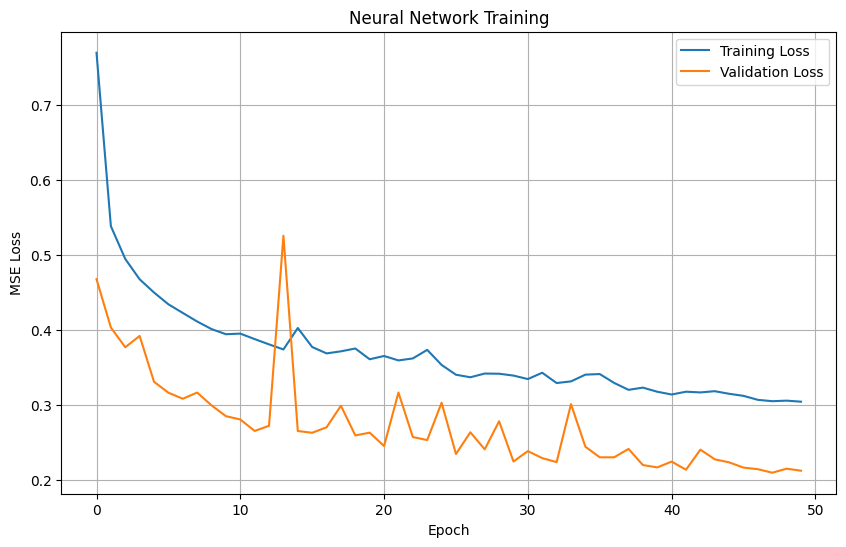

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss",
)

plt.plot(
    val_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network Training")

plt.legend()
plt.grid(True)

plt.show()

In [47]:
batch_size = 32768
model.eval()

predictions_scaled = []

with torch.no_grad():

    for i in range(0, len(X_test_tensor), batch_size):

        X_batch = X_test_tensor[
            i:i + batch_size
        ].to(device)

        prediction = model(X_batch)

        predictions_scaled.append(
            prediction.cpu().numpy()
        )

Y_pred_scaled = np.concatenate(
    predictions_scaled,
    axis=0,
)

Y_pred = Y_scaler.inverse_transform(
    Y_pred_scaled
)

print("Prediction shape:", Y_pred.shape)

Prediction shape: (100000, 8)


In [48]:
results = []

for i, name in enumerate(target_names):

    rmse = np.sqrt(
        mean_squared_error(
            Y_test[:, i],
            Y_pred[:, i],
        )
    )

    mae = mean_absolute_error(
        Y_test[:, i],
        Y_pred[:, i],
    )

    r2 = r2_score(
        Y_test[:, i],
        Y_pred[:, i],
    )

    results.append({
        "Target": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

normal_results = pd.DataFrame(results)

print(normal_results.to_string(index=False))

        Target         RMSE          MAE       R2
      position 1.273853e+12 3.000426e+11 0.857840
      velocity 5.474570e+07 2.197851e+07 0.820402
          beta 1.824127e-01 7.347072e-02 0.820794
         gamma 1.185149e+04 1.026187e+03 0.174823
      momentum 9.287020e+13 9.554971e+12 0.719686
kinetic_energy 2.768796e+22 2.341394e+21 0.664891
  total_energy 2.788102e+22 2.969849e+21 0.738631
   proper_time 2.782823e+03 8.078788e+02 0.923345


In [49]:
extreme_data = np.load(
    "relativistic_extreme_test_10k.npy"
)

print("Extreme dataset shape:", extreme_data.shape)

Extreme dataset shape: (10000, 13)


In [50]:
X_extreme = extreme_data[:, :5]
Y_extreme = extreme_data[:, 5:13]

X_extreme_scaled = X_scaler.transform(
    X_extreme
)

X_extreme_tensor = torch.tensor(
    X_extreme_scaled,
    dtype=torch.float32,
)

In [51]:
extreme_predictions_scaled = []

with torch.no_grad():

    for i in range(
        0,
        len(X_extreme_tensor),
        batch_size,
    ):

        X_batch = X_extreme_tensor[
            i:i + batch_size
        ].to(device)

        prediction = model(X_batch)

        extreme_predictions_scaled.append(
            prediction.cpu().numpy()
        )

Y_extreme_pred_scaled = np.concatenate(
    extreme_predictions_scaled,
    axis=0,
)

Y_extreme_pred = Y_scaler.inverse_transform(
    Y_extreme_pred_scaled
)

print(
    "Extreme prediction shape:",
    Y_extreme_pred.shape,
)

Extreme prediction shape: (10000, 8)


In [52]:
extreme_results = []

for i, name in enumerate(target_names):

    rmse = np.sqrt(
        mean_squared_error(
            Y_extreme[:, i],
            Y_extreme_pred[:, i],
        )
    )

    mae = mean_absolute_error(
        Y_extreme[:, i],
        Y_extreme_pred[:, i],
    )

    r2 = r2_score(
        Y_extreme[:, i],
        Y_extreme_pred[:, i],
    )

    extreme_results.append({
        "Target": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

extreme_results = pd.DataFrame(
    extreme_results
)

print(
    extreme_results.to_string(
        index=False
    )
)

        Target         RMSE          MAE       R2
      position 1.288917e+12 2.831697e+11 0.853154
      velocity 5.203084e+07 2.062507e+07 0.829645
          beta 1.731933e-01 6.891276e-02 0.830356
         gamma 1.658400e+04 1.136401e+03 0.143934
      momentum 7.678704e+13 9.343680e+12 0.804846
kinetic_energy 2.265538e+22 2.258313e+21 0.764168
  total_energy 2.256252e+22 2.907640e+21 0.826429
   proper_time 2.455696e+03 7.483043e+02 0.935063


In [53]:
normal_predictions_df = pd.DataFrame(
    Y_pred,
    columns=target_names,
)

normal_predictions_df.to_csv(
    "neural_network_200_normal_predictions.csv",
    index=False,
)

extreme_predictions_df = pd.DataFrame(
    Y_extreme_pred,
    columns=target_names,
)

extreme_predictions_df.to_csv(
    "neural_network_200_extreme_predictions.csv",
    index=False,
)

normal_results.to_csv(
    "neural_network_200_normal_metrics.csv",
    index=False,
)

extreme_results.to_csv(
    "neural_network_200_extreme_metrics.csv",
    index=False,
)

print("Prediction and metric CSV files saved.")

Prediction and metric CSV files saved.


In [54]:
model_path = "/neural_network_200.pt"

torch.save(
    model.state_dict(),
    model_path,
)

print("Model saved:", model_path)

Model saved: /neural_network_200.pt


In [57]:
variables_to_delete = [
    "data",
    "X",
    "Y",
    "X_train",
    "X_temp",
    "X_val",
    "X_test",
    "Y_train",
    "Y_temp",
    "Y_val",
    "Y_test",
    "X_train_scaled",
    "X_val_scaled",
    "X_test_scaled",
    "Y_train_scaled",
    "Y_val_scaled",
    "Y_test_scaled",
    "X_train_tensor",
    "Y_train_tensor",
    "X_val_tensor",
    "Y_val_tensor",
    "X_test_tensor",
    "Y_test_tensor",
    "train_dataset",
    "val_dataset",
    "train_loader",
    "val_loader",
    "extreme_data",
    "X_extreme",
    "Y_extreme",
    "X_extreme_scaled",
    "X_extreme_tensor",
    "predictions_scaled",
    "extreme_predictions_scaled",
    "Y_pred_scaled",
    "Y_extreme_pred_scaled",
    "best_model_state",
]

for name in variables_to_delete:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("RAM cleanup complete.")

RAM cleanup complete.
